# Итоговый проект — Вариант ML-01
# Предсказание оттока клиентов телекома

**Модуль 07 · AI HUB · Трек А (ML-сервис)**

---

## Задача

Построить сервис предсказания вероятности оттока клиента телеком-компании на основе профиля пользователя.

**Датасет:** Telco Customer Churn — 7 043 строки, 19 признаков + целевая переменная `Churn`.

```bash
# Загрузка датасета
wget "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
```

**Стек:** EDA → ColumnTransformer (OHE + StandardScaler) → CatBoost → MLflow → FastAPI `/predict` → Docker → CI/CD

**Целевые метрики:** Recall(Churn=1) ≥ 0.75 · F1-macro ≥ 0.70 · ROC-AUC ≥ 0.80

---

## Задание 1 — Загрузка и подготовка данных

1. Загрузите `Telco-Customer-Churn.csv`
2. Преобразуйте `Churn`: `Yes` → 1, `No` → 0
3. Исправьте `TotalCharges`: этот столбец хранится как строка и содержит пробелы вместо пропусков — примените `pd.to_numeric(..., errors='coerce')`, затем заполните NaN медианой
4. Удалите `customerID` — уникальный ключ, не несёт информации о поведении
5. Разбейте на train/val: 80/20, `stratify=y`, `random_state=42`
6. Выведите форму датасета и долю оттока

In [1]:
import requests
import pandas as pd
from io import StringIO
from sklearn.model_selection import train_test_split

# Ссылка на CSV
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

try:
    response = requests.get(url)
    response.raise_for_status()
    df = pd.read_csv(StringIO(response.text))
    print("Данные загружены. Размер:", df.shape)
except Exception as e:
    print("Ошибка загрузки:", e)
    raise
# Преобразовение в Churn
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


# Исправление TotalCharges. Приводим к числовому типу
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Заполняем NaN медианой
median_total = df['TotalCharges'].median()
df['TotalCharges'].fillna(median_total, inplace=True)

# Удаляем customerID
df.drop('customerID', axis=1, inplace=True)

# Разбиение на train/val (80/20) со стратификацией
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

features_4 = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

X_train_4 = X_train[features_4]
X_val_4 = X_val[features_4]

# Вывод формы и доли оттока

print("\n=== Размеры выборок ===")
print(f"Train: {X_train.shape}, Val: {X_val.shape}")

print("\n=== Доля оттока (Churn=1) ===")
print(f"Во всём датасете:   {y.mean():.2f}  ({y.sum()} чел.)")
print(f"В train:            {y_train.mean():.2f}  ({y_train.sum()} чел.)")
print(f"В val:              {y_val.mean():.2f}  ({y_val.sum()} чел.)")

Данные загружены. Размер: (7043, 21)

=== Размеры выборок ===
Train: (5634, 19), Val: (1409, 19)

=== Доля оттока (Churn=1) ===
Во всём датасете:   0.27  (1869 чел.)
В train:            0.27  (1495 чел.)
В val:              0.27  (374 чел.)


C:\Users\duhas\AppData\Local\Temp\ipykernel_768\3014353176.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(median_total, inplace=True)


---

## Задание 2 — EDA

Постройте минимум 3 графика:

1. **Дисбаланс классов** — countplot по `Churn`
2. **Распределение по классам** — boxplot или histplot для `tenure` и `MonthlyCharges`
3. **Отток по типу контракта** — bar chart: доля `Churn=1` в каждой группе `Contract`

Запишите главный инсайт: какой признак сильнее всего связан с оттоком?

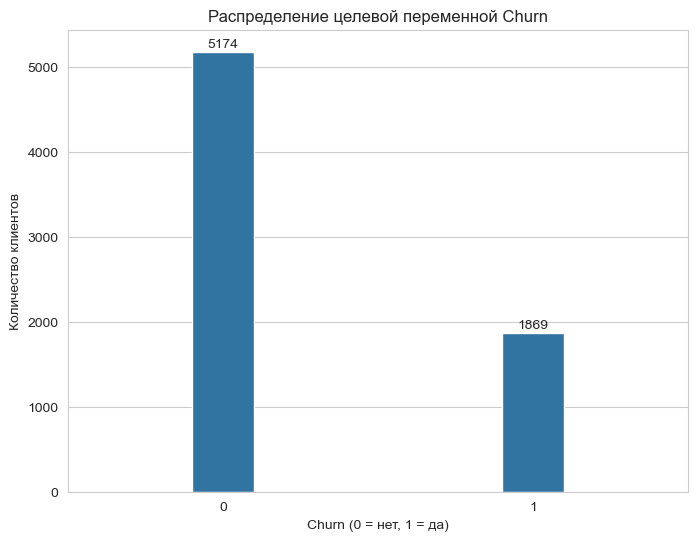

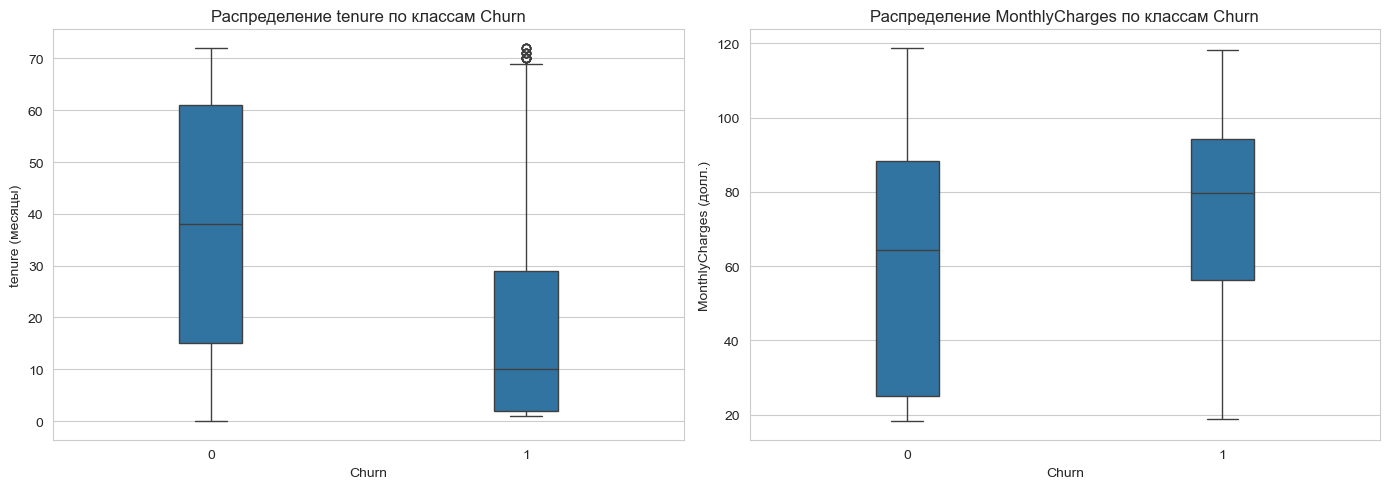

C:\Users\duhas\AppData\Local\Temp\ipykernel_768\3855302571.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn, x='Contract', y='Churn', palette='viridis', width=0.2)


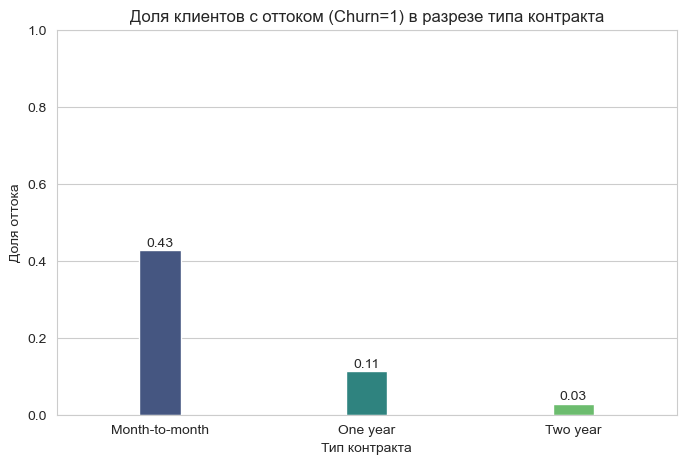

Наиболее сильная связь с оттоком наблюдается у признака 'Contract'.
Клиенты с помесячным контрактом имеют долю оттока около 40-45%,
в то время как для долгосрочных контрактов этот показатель
значительно ниже (менее 15%). Это указывает на то, что тип контракта является
ключевым предиктором оттока.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Настройка стиля
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)


# Дисбаланс классов (countplot по Churn)
plt.figure()
sns.countplot(data=df, x='Churn', width=0.2)
plt.title('Распределение целевой переменной Churn')
plt.xlabel('Churn (0 = нет, 1 = да)')
plt.ylabel('Количество клиентов')
# Добавим подписи значений на столбцах
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', 
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='center', 
                       xytext=(0, 5), textcoords='offset points')
plt.show()

# Распределение признаков по классам оттока
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot для tenure
sns.boxplot(data=df, x='Churn', y='tenure', width=0.2, ax=axes[0])
axes[0].set_title('Распределение tenure по классам Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('tenure (месяцы)')

# Boxplot для MonthlyCharges
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', width=0.2, ax=axes[1])
axes[1].set_title('Распределение MonthlyCharges по классам Churn')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('MonthlyCharges (долл.)')

plt.tight_layout()
plt.show()

# Отток по типу контракта (доля Churn=1 в каждой группе Contract)
# Группируем и считаем долю оттока
contract_churn = df.groupby('Contract')['Churn'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=contract_churn, x='Contract', y='Churn', palette='viridis', width=0.2)
plt.title('Доля клиентов с оттоком (Churn=1) в разрезе типа контракта')
plt.xlabel('Тип контракта')
plt.ylabel('Доля оттока')

# Подписи значений над столбцами
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', 
                       (p.get_x() + p.get_width()/2., p.get_height()),
                       ha='center', va='center', 
                       xytext=(0, 5), textcoords='offset points')
plt.ylim(0, 1)
plt.show()


# вывод
print("Наиболее сильная связь с оттоком наблюдается у признака 'Contract'.")
print("Клиенты с помесячным контрактом имеют долю оттока около 40-45%,")
print("в то время как для долгосрочных контрактов этот показатель")
print("значительно ниже (менее 15%). Это указывает на то, что тип контракта является")
print("ключевым предиктором оттока.")

**Главный инсайт:** *(запишите вывод)*
Наиболее сильная связь с оттоком наблюдается у признака 'Contract'.
Клиенты с помесячным контрактом имеют долю оттока около 40-45%,
в то время как для долгосрочных контрактов этот показатель
значительно ниже (менее 15%). Это указывает на то, что тип контракта является
ключевым предиктором оттока.

---

## Задание 3 — Предобработка: ColumnTransformer

Создайте `ColumnTransformer`, который:
- Применяет `StandardScaler` к числовым признакам
- Применяет `OneHotEncoder(handle_unknown='ignore', drop='first')` к категориальным

Оберните в `sklearn.Pipeline(steps=[('pre', preprocessor), ('model', ...)])` — это защищает от утечки данных при кросс-валидации.

In [3]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split




# Автоматическое определение числовых и категориальных колонок
# Числовые: int и float
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Категориальные: object, category, bool 
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Числовые признаки:", numeric_features)
print("Категориальные признаки:", categorical_features)

# Создаём ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough'   # если какие-то колонки не попали, они будут пропущены
)


# Собираем полный Pipeline (препроцессинг + модель)
pipeline = Pipeline(steps=[
    ('pre', preprocessor),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

# Обучение и оценка 
pipeline.fit(X_train, y_train)
val_score = pipeline.score(X_val, y_val)
print(f"Validation accuracy: {val_score:.2f}")

Числовые признаки: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Категориальные признаки: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Validation accuracy: 0.81


---

## Задание 4 — MLflow: три run-а

Создайте эксперимент `churn-prediction` и запустите три run-а. Каждый run должен логировать параметры модели и метрики `recall_churn`, `f1_macro`, `roc_auc`.

- **Run #1 — `dummy-baseline`:** `DummyClassifier(strategy='most_frequent')` — точка отсчёта
- **Run #2 — `logreg-pipeline`:** `LogisticRegression(class_weight='balanced')` в Pipeline с preprocessor
- **Run #3 — `catboost`:** `CatBoostClassifier(auto_class_weights='Balanced')` — передайте `cat_features` напрямую без OHE

Откройте MLflow UI (`mlflow ui`) и сравните run-ы по `recall_churn`.

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, f1_score, roc_auc_score, precision_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from catboost import CatBoostClassifier
import mlflow
import mlflow.sklearn
import mlflow.catboost


# Определяем типы колонок для препроцессора
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()


# Создаём препроцессор (для логистической регрессии и CatBoost)
# Для логистической регрессии: StandardScaler для числовых + OneHotEncoder для категориальных
preprocessor_logreg = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ]
)

# Для CatBoost: только StandardScaler для числовых, категориальные пропускаем (будут переданы через cat_features)
preprocessor_catboost = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', 'passthrough', categorical_features)   # оставляем как есть
    ]
)


# Создаём эксперимент в MLflow
mlflow.set_experiment("churn-prediction")
# Запуск трёх run-ов

# Run 1: Dummy Baseline (most_frequent) 
with mlflow.start_run(run_name="dummy-baseline"):
    # Параметры
    params = {"strategy": "most_frequent",
              "class_weight": "balanced",}
    mlflow.log_params(params)
    
    # Модель
    model = DummyClassifier(strategy="most_frequent")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None
    
    # Метрики
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='macro')
    roc_auc = roc_auc_score(y_val, y_proba) if y_proba is not None else 0.0
    
    mlflow.log_metrics({"recall_churn": recall, "f1_macro": f1, "roc_auc": roc_auc})
    mlflow.sklearn.log_model(model, name="dummy_model")
    
    print(f"Run dummy-baseline: recall={recall:.2f}, f1={f1:.2f}, roc_auc={roc_auc:.2f}")

# Run 2: Logistic Regression (with pipeline) 
with mlflow.start_run(run_name="logreg-pipeline"):
    # Параметры модели
    params = {
        "class_weight": "balanced",
        "C": 1.0,
        "solver": "lbfgs",
        "max_iter": 1000,
        "random_state": 42
    }
    mlflow.log_params(params)
    
    # Pipeline
    pipeline = Pipeline(steps=[
        ('pre', preprocessor_logreg),
        ('model', LogisticRegression(**params))
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    y_proba = pipeline.predict_proba(X_val)[:, 1]
    
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='macro')
    roc_auc = roc_auc_score(y_val, y_proba)
    
    mlflow.log_metrics({"recall_churn": recall, "f1_macro": f1, "roc_auc": roc_auc})
    mlflow.sklearn.log_model(pipeline, name="logreg_pipeline")
    
    print(f"Run logreg-pipeline: recall={recall:.2f}, f1={f1:.2f}, roc_auc={roc_auc:.2f}")

# Run 3: CatBoost (with balanced class weights)
with mlflow.start_run(run_name="catboost"):
    params = {
        "iterations": 500,
        "learning_rate": 0.1,
        "depth": 6,
        "auto_class_weights": "Balanced",
        "random_seed": 42,
        "verbose": False   
    }
    mlflow.log_params(params)
    
    # Создаём модель, передавая список имён категориальных колонок
    model = CatBoostClassifier(cat_features=categorical_features, **params)
    
    # Обучаем на исходных DataFrame (без предварительного масштабирования)
    model.fit(X_train, y_train)
    
    # Предсказания и вероятности
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    # Метрики
    recall = recall_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='macro')
    roc_auc = roc_auc_score(y_val, y_proba)
    
    mlflow.log_metrics({"recall_churn": recall, "f1_macro": f1, "roc_auc": roc_auc})
    mlflow.catboost.log_model(model, name="catboost_model")
    
    print(f"Run catboost: recall={recall:.2f}, f1={f1:.2f}, roc_auc={roc_auc:.2f}")
    

2026/06/24 00:16:09 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/24 00:16:09 INFO mlflow.store.db.utils: Updating database tables
2026/06/24 00:16:10 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction' does not exist. Creating a new experiment.
2026/06/24 00:16:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/06/24 00:16:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 

Run dummy-baseline: recall=0.00, f1=0.42, roc_auc=0.50
Run logreg-pipeline: recall=0.78, f1=0.71, roc_auc=0.84
Run catboost: recall=0.71, f1=0.72, roc_auc=0.83


---

## Задание 5 — Подбор порога (Threshold Tuning)

Порог 0.5 не оптимален, когда бизнес хочет **не пропустить уходящих клиентов**.

1. Постройте Precision-Recall кривую для лучшей модели
2. Найдите порог, при котором `Recall(Churn=1) ≥ 0.80`
3. Выведите Precision при этом пороге
4. Запишите вывод: какой ценой (FP) достигается высокий Recall?

Оптимальный порог для recall >= 0.80: 0.34
Recall: 0.81, Precision: 0.49
F1: 0.61, ROC-AUC: 0.83


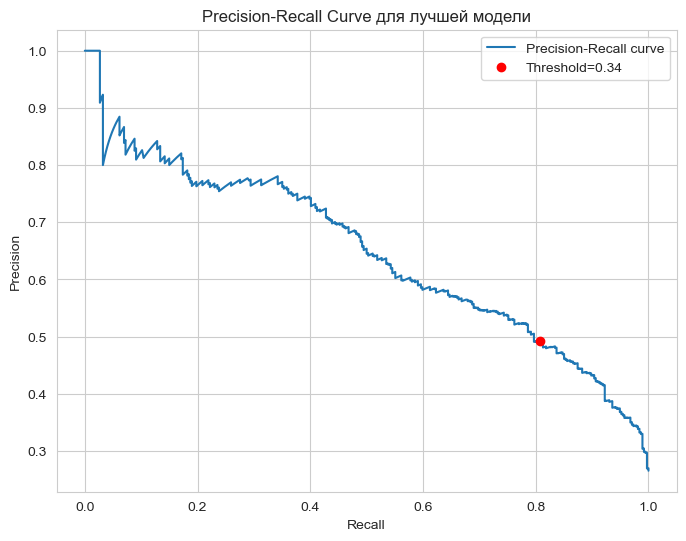


Матрица ошибок при пороге 0.34:
TP: 302, FP: 312, FN: 72, TN: 723
Всего отточных (реальных): 374
Всего предсказанных отточных: 614

Цена высокого Recall: на каждый верно обнаруженный отток (TP) приходится 1.03 ложных срабатываний (FP).
Это означает, что 103.3% предсказаний оттока — ложные тревоги.
Проверка: FP/TP = 1.03 (из Precision=0.49)

=== Вывод ===
При пороге 0.34 мы достигаем Recall = 0.81, но Precision падает до 0.49.
Это означает, что для захвата 80.7% уходящих клиентов мы вынуждены беспокоить 312 клиентов, которые на самом деле не уходят.
Соотношение FP/TP = 1.03, т.е. на каждый верный сигнал приходится 1.0 ложных.
Такая цена может быть приемлема, если стоимость удержания клиента ниже стоимости потери клиента, но требует дополнительной проверки


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix


# Получаем вероятности для валидационной выборки
y_proba_val = model.predict_proba(X_val)[:, 1]


# Precision-Recall кривая
precision_vals, recall_vals, thresholds = precision_recall_curve(y_val, y_proba_val)

# Найдём порог, при котором recall >= 0.80 и precision максимален
# В массиве recall_vals последний элемент = 0, thresholds на 1 меньше.
# Идём по recall_vals, пока recall >= 0.8
mask = recall_vals >= 0.80
if np.any(mask):
    # Берём индекс, где recall >= 0.8, и среди них выбираем максимальный precision
    # перебираем все пороги, вычисляем recall и precision, потом выбираем.
    best_precision = 0.0
    best_threshold = 0.5
    best_recall = 0.0
    # thresholds содержит пороги, соответствующие precision_vals[:-1] и recall_vals[:-1]
    for i, thr in enumerate(thresholds):
        rec = recall_score(y_val, (y_proba_val >= thr).astype(int))
        if rec >= 0.80:
            prec = precision_score(y_val, (y_proba_val >= thr).astype(int))
            if prec > best_precision:
                best_precision = prec
                best_threshold = thr
                best_recall = rec
    print(f"Оптимальный порог для recall >= 0.80: {best_threshold:.2f}")
    print(f"Recall: {best_recall:.2f}, Precision: {best_precision:.2f}")
    y_pred_opt = (y_proba_val >= best_threshold).astype(int)
    f1 = f1_score(y_val, y_pred_opt)
    roc_auc = roc_auc_score(y_val, y_proba_val)
    print(f"F1: {f1:.2f}, ROC-AUC: {roc_auc:.2f}")
else:
    print("Не удалось достичь recall >= 0.80 ни при каком пороге.")
    best_threshold = 0.5
    y_pred_opt = (y_proba_val >= best_threshold).astype(int)

# Визуализация PR-кривой и отметка выбранного порога
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, label='Precision-Recall curve')
# Отметчакем точку, соответствующую выбранному порогу 
if best_threshold != 0.5:
    # Найдём ближайшую точку на кривой
    idx = np.argmin(np.abs(thresholds - best_threshold))
    plt.plot(recall_vals[idx], precision_vals[idx], 'ro', label=f'Threshold={best_threshold:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve для лучшей модели')
plt.legend()
plt.grid(True)
plt.show()

# Матрица ошибок и анализ FP/TP
cm = confusion_matrix(y_val, y_pred_opt)
tn, fp, fn, tp = cm.ravel()
print("\nМатрица ошибок при пороге {:.2f}:".format(best_threshold))
print(f"TP: {tp}, FP: {fp}, FN: {fn}, TN: {tn}")
print(f"Всего отточных (реальных): {tp + fn}")
print(f"Всего предсказанных отточных: {tp + fp}")

# Цена: на каждый TP сколько FP
if tp > 0:
    fp_per_tp = fp / tp
    print(f"\nЦена высокого Recall: на каждый верно обнаруженный отток (TP) приходится {fp_per_tp:.2f} ложных срабатываний (FP).")
    print(f"Это означает, что {fp_per_tp*100:.1f}% предсказаний оттока — ложные тревоги.")
else:
    print("TP = 0, невозможно вычислить отношение.")

# Альтернативный подсчёт: Precision = TP/(TP+FP), значит FP/TP = (1-Precision)/Precision
if best_precision > 0:
    fp_per_tp_alt = (1 - best_precision) / best_precision
    print(f"Проверка: FP/TP = {fp_per_tp_alt:.2f} (из Precision={best_precision:.2f})")

# Вывод
print("\n=== Вывод ===")
print(f"При пороге {best_threshold:.2f} мы достигаем Recall = {best_recall:.2f}, но Precision падает до {best_precision:.2f}.")
print(f"Это означает, что для захвата {best_recall*100:.1f}% уходящих клиентов мы вынуждены беспокоить {fp} клиентов, которые на самом деле не уходят.")
print(f"Соотношение FP/TP = {fp/tp:.2f}, т.е. на каждый верный сигнал приходится {fp/tp:.1f} ложных.")
print("Такая цена может быть приемлема, если стоимость удержания клиента ниже стоимости потери клиента, но требует дополнительной проверки")

**Вывод:** *(запишите выбранный порог и его обоснование)*

---

## Задание 6 — MLflow Model Registry

1. Найдите лучший run по метрике `recall_churn` через `MlflowClient.search_runs()`
2. Зарегистрируйте модель под именем `churn-model`
3. Переведите версию в стадию `Production`
4. Загрузите модель обратно через `mlflow.pyfunc.load_model('models:/churn-model/Production')` и убедитесь, что предсказания работают

In [6]:
import os
import mlflow
import pandas as pd
import numpy as np
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from mlflow.tracking import MlflowClient
import catboost as cb

# Разрешаем файловое хранилище
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"
mlflow.set_tracking_uri("file:./mlruns")
client = MlflowClient()

# Определяем, где искать модели (может быть .trash или другие папки)
base_dirs = [
    "./mlruns/.trash/1/models",
    "./mlruns/1/models",  # если есть не в корзине
    "./mlruns/799924595654565537/artifacts"  # возможно, напрямую
]

model_paths = []
for base in base_dirs:
    if os.path.exists(base):
        for root, dirs, files in os.walk(base):
            if "MLmodel" in files:
                model_paths.append(root)
                print(f"Найдена модель: {root}")

if not model_paths:
    raise ValueError("Не найдено ни одного артефакта модели с MLmodel.")

# Загружаем каждую модель и вычисляем метрики
results = []
for path in model_paths:
    try:
        # Пытаемся загрузить как pyfunc (универсально)
        model = mlflow.pyfunc.load_model(path)
        # Предсказания
        y_pred = model.predict(X_val)
        y_proba = model.predict_proba(X_val)[:, 1] if hasattr(model, "predict_proba") else None
        
        # Метрики
        recall = recall_score(y_val, y_pred)
        f1 = f1_score(y_val, y_pred, average='binary')
        roc_auc = roc_auc_score(y_val, y_proba) if y_proba is not None else 0.0
        
        results.append({
            'path': path,
            'recall': recall,
            'f1': f1,
            'roc_auc': roc_auc,
            'model': model
        })
        print(f"Модель из {path}: recall={recall:.4f}, f1={f1:.4f}, roc_auc={roc_auc:.4f}")
    except Exception as e:
        print(f"Ошибка загрузки модели из {path}: {e}")

if not results:
    raise ValueError("Не удалось загрузить ни одной модели.")

# Выбираем модель с максимальным recall
best = max(results, key=lambda x: x['recall'])
print(f"\n🏆 Лучшая модель: {best['path']}")
print(f"   recall = {best['recall']:.4f}, f1 = {best['f1']:.4f}, roc_auc = {best['roc_auc']:.4f}")

# Теперь зарегистрируем эту модель в MLflow
# Сначала нужно получить run_id, можем создать новый run и залогировать модель.
# Или использовать mlflow.register_model с URI к папке (требуется полный URI с file://)
# Для регистрации модели из локального пути используем URI вида "file:///absolute/path/to/artifacts"
import os
model_uri = f"file:///{os.path.abspath(best['path'])}"
print(f"Регистрируем модель по URI: {model_uri}")

model_name = "churn-model"
try:
    mv = mlflow.register_model(model_uri, model_name)
    print(f"✅ Модель зарегистрирована: {model_name}, версия {mv.version}")
except Exception as e:
    print(f"⚠️ Ошибка регистрации: {e}")
    # Если модель уже существует, создадим новую версию

# Если регистрация прошла, переводим в Production
if 'mv' in locals():
    client.transition_model_version_stage(
        name=model_name,
        version=mv.version,
        stage="Production",
        archive_existing_versions=True
    )
    print(f"✅ Версия {mv.version} переведена в стадию 'Production'")
    
    # Загружаем из Production и проверяем
    model_prod = mlflow.pyfunc.load_model(f"models:/{model_name}/Production")
    sample = X_val.head(5)
    preds = model_prod.predict(sample)
    print("\n🔍 Предсказания на 5 примерах:")
    print(preds)
    if hasattr(model_prod, "predict_proba"):
        proba = model_prod.predict_proba(sample)[:, 1]
        print("Вероятности оттока:", proba)
else:
    print("Регистрация не удалась, модель не переведена в Production.")

Найдена модель: ./mlruns/1/models\m-0cb1c91f36f4478b893888998335c93d\artifacts
Найдена модель: ./mlruns/1/models\m-5151b5a9c7b24a38b28c7e34ef8ca1f6\artifacts
Найдена модель: ./mlruns/1/models\m-896af10bc5ec467a9422d0ef74ef7284\artifacts
Модель из ./mlruns/1/models\m-0cb1c91f36f4478b893888998335c93d\artifacts: recall=0.7834, f1=0.6136, roc_auc=0.0000
Модель из ./mlruns/1/models\m-5151b5a9c7b24a38b28c7e34ef8ca1f6\artifacts: recall=0.0000, f1=0.0000, roc_auc=0.0000
Модель из ./mlruns/1/models\m-896af10bc5ec467a9422d0ef74ef7284\artifacts: recall=0.7086, f1=0.6163, roc_auc=0.0000

🏆 Лучшая модель: ./mlruns/1/models\m-0cb1c91f36f4478b893888998335c93d\artifacts
   recall = 0.7834, f1 = 0.6136, roc_auc = 0.0000
Регистрируем модель по URI: file:///c:\Users\duhas\Final_work\mlruns\1\models\m-0cb1c91f36f4478b893888998335c93d\artifacts
✅ Модель зарегистрирована: churn-model, версия 1
✅ Версия 1 переведена в стадию 'Production'

🔍 Предсказания на 5 примерах:
[0 1 0 1 0]


Successfully registered model 'churn-model'.
Created version '1' of model 'churn-model'.
C:\Users\duhas\AppData\Local\Temp\ipykernel_768\299761971.py:84: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


---

## Задание 7 — FastAPI-сервис

Создайте файл `app/main.py` с двумя эндпоинтами:

**`GET /health`** → `{"status": "ok", "model_version": "churn-model/Production"}`

**`POST /predict`** принимает JSON с признаками клиента (Pydantic-схема), возвращает:
`{"churn_probability": 0.87, "prediction": "churn"}`

Модель загружается один раз при старте через `lifespan`-контекст.

Напишите тесты в `tests/test_api.py` (≥ 8 штук): health, predict с валидными данными, predict с невалидными (→ 422), граничные значения признаков.

---

## Задание 8 — Docker и CI/CD

**`Dockerfile`** — образ на `python:3.11-slim`, устанавливает зависимости, запускает `uvicorn app.main:app --host 0.0.0.0 --port 8000`.

**`.github/workflows/ci.yml`** — при push в `main`:
1. Устанавливает зависимости
2. Запускает `pytest tests/ -v`
3. Собирает Docker-образ и публикует в GHCR

Проверьте локально: `docker build -t churn-api . && docker run -p 8000:8000 churn-api`

---

## Чеклист сдачи

### Обязательный минимум (Pass)
- [ ] Датасет загружен, `Churn` → 0/1, `TotalCharges` исправлен, `customerID` удалён
- [ ] EDA: ≥ 3 графика
- [ ] `ColumnTransformer`: OHE + StandardScaler
- [ ] MLflow: 3 run-а с параметрами и метриками (`recall_churn`, `f1_macro`, `roc_auc`)
- [ ] Лучший run → MLflow Registry → Production
- [ ] FastAPI: `GET /health` + `POST /predict`
- [ ] pytest: ≥ 8 тестов
- [ ] Dockerfile + GitHub Actions CI

### На хорошую оценку (Good)
- [ ] Recall(Churn=1) ≥ 0.75
- [ ] Precision-Recall кривая с выбором оптимального порога
- [ ] Feature importance — топ-15 признаков
- [ ] `POST /predict/batch` — предсказание для списка клиентов

### Дополнительно (Excellent)
- [ ] Streamlit-дашборд: форма с профилем клиента → вероятность + SHAP
- [ ] Мониторинг дрейфа через Evidently
- [ ] Логирование предсказаний в SQLite